<a href="https://colab.research.google.com/github/davronprogammer/Image_classification_garbage/blob/main/15_dars_mini_project_uzum_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

df = pd.read_csv('/content/uzum_orders.csv')
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        2000 non-null   int64  
 1   filial          2000 non-null   object 
 2   kategoriya      2000 non-null   object 
 3   narx            2000 non-null   float64
 4   yetkazish_kuni  2000 non-null   int64  
 5   mijoz_yoshi     2000 non-null   int64  
 6   reyting         1982 non-null   float64
 7   takroriy        2000 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 125.1+ KB


In [5]:
df.describe()

,order_id,narx,yetkazish_kuni,mijoz_yoshi,reyting,takroriy
count,2000.000000,2000.000000,2000.000000,2000.000000,1982.000000,2000.000000
mean,2000.500000,143.679050,3.987000,33.712000,4.218163,0.499500
std,577.494589,70.488548,1.991686,9.015303,0.573857,0.500125
min,1001.000000,12.000000,1.000000,16.000000,2.300000,0.000000
25%,1500.750000,95.475000,2.000000,28.000000,3.800000,0.000000
50%,2000.500000,132.000000,4.000000,33.000000,4.200000,0.000000
75%,2500.250000,175.525000,6.000000,40.000000,4.700000,1.000000
max,3000.000000,498.000000,7.000000,65.000000,5.000000,1.000000


Dataset 2000 ta buyurtmadan iborat bo‘lib, faqat reyting ustunida 18 ta (0.9%) yetishmayotgan qiymat bor. order_id esa faqat identifikator bo‘lib, model uchun ishlatilmaydi.

Narx (narx) o‘rtacha 143.68, median 132, min 12, max 498. Std = 70.49 bo‘lgani uchun narxlar ancha keng tarqalgan.
Yetkazish kuni o‘rtacha 4 kun, mijoz yoshi esa 33.7 yosh. Ularning std qiymatlari mos ravishda 1.99 va 9.02, ya’ni yetkazish muddati kamroq, yosh esa kengroq tarqalgan.
Reyting o‘rtacha 4.22 bo‘lib, mijozlar asosan yuqori baho bergan. Takroriy ustunida o‘rtacha 0.4995, ya’ni xaridorlar deyarli teng ikkiga bo‘lingan.

In [4]:
df.isnull().sum()

,0
order_id,0
filial,0
kategoriya,0
narx,0
yetkazish_kuni,0
mijoz_yoshi,0
reyting,18
takroriy,0


Dataset 2000 ta kuzatuv va 8 ta ustundan iborat. Ma'lumotlar asosan to'liq, faqat reyting ustunida 18 ta bo'sh qiymat mavjud. Ustunlarning ma'lumot turlari to'g'ri aniqlangan va dataset keyingi tozalash bosqichiga tayyor.

## **Data cleaning**

In [6]:
df = df.dropna(subset=['reyting'])

In [7]:
df.isnull().sum()
print(df.shape)

(1982, 8)


reyting ustunida faqat 18 ta (0.9%) missing value mavjud bo'lganligi sababli, ularni median bilan to'ldirish o'rniga olib tashlandi. Bu sun'iy qiymatlar kiritilishining oldini oladi va statistik tahlilning ishonchliligini saqlaydi.

In [8]:
df.duplicated().sum()

np.int64(0)

## **Outlier Detection**

In [10]:
import plotly.express as px

fig = px.box(
    df,
    y='narx',
    title="Narx bo'yicha boxplot",
    template='plotly_dark'
)

fig.show()

Boxplot narx ustunida bir nechta yuqori qiymatlar mavjudligini ko'rsatmoqda. Ushbu qiymatlar outlier bo'lishi mumkin. Keyingi bosqichda IQR usuli yordamida ularning chegaralari hisoblanadi va ular haqiqatan ham ekstremal qiymatlar ekanligi tekshiriladi.

In [12]:
Q1 = df["narx"].quantile(0.25)
Q3 = df["narx"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-24.650000000000006
296.35


In [13]:
outliers = df[(df["narx"] < lower) | (df["narx"] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 74


In [14]:
df = df[(df["narx"] >= lower) & (df["narx"] <= upper)]
print(df.shape)

(1908, 8)


IQR usuli yordamida narx ustunida 74 ta ekstremal qiymat aniqlandi. Bu qiymatlar umumiy kuzatuvlarning taxminan 3.7% ini tashkil qiladi. Statistik tahlil natijalariga ortiqcha ta'sir qilmasligi uchun ushbu outlierlar datasetdan olib tashlandi.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1908 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1908 non-null   int64  
 1   filial          1908 non-null   object 
 2   kategoriya      1908 non-null   object 
 3   narx            1908 non-null   float64
 4   yetkazish_kuni  1908 non-null   int64  
 5   mijoz_yoshi     1908 non-null   int64  
 6   reyting         1908 non-null   float64
 7   takroriy        1908 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 134.2+ KB


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1908.0,1998.521488,577.576547,1001.0,1497.75,1999.50,2500.250,3000.0
narx,1908.0,135.686268,57.028880,12.0,94.70,129.80,168.625,295.7
yetkazish_kuni,1908.0,3.974843,1.988535,1.0,2.00,4.00,6.000,7.0
mijoz_yoshi,1908.0,33.614780,9.017837,16.0,27.75,33.00,40.000,65.0
reyting,1908.0,4.221646,0.570134,2.3,3.80,4.25,4.700,5.0
takroriy,1908.0,0.496331,0.500118,0.0,0.00,0.00,1.000,1.0


## **Exploratory Data Analysis (EDA)**




In [22]:
# 1-grafik — Histogram + KDE

import plotly.express as px

fig = px.histogram(
    df,
    x='narx',
    nbins=50,
    marginal='box',
    opacity=0.8,
    template='plotly_dark',
    title="Narx bo'yicha taqsimot"
)

fig.add_vline(
    x=df['narx'].mean(),
    line_width=3,
    line_dash='dash',
    line_color='red',
    annotation_text='O\'rtacha narx'
)

fig.add_vline(
    x=df["narx"].median(),
    line_dash="dash",
    line_color="blue",
    annotation_text="Median"

)

fig.show()


Buyurtma qiymatlarining asosiy qismi past va o'rta narx oralig'ida jamlangan. O'rtacha qiymat medianadan biroz yuqoriroq bo'lgani sababli taqsimot o'ng tomonga qiyshayganligini (right-skewed) ko'rish mumkin. Bu yuqori narxdagi buyurtmalar soni kam bo'lsa-da, o'rtacha qiymatni oshirayotganini bildiradi.

In [26]:
# 2-grafik — Filiallar bo'yicha narx taqsimoti

fig = px.box(
    df,
    x="filial",
    y="narx",
    color="filial",
    title="Distribution of Order Prices by Branch",
    template="plotly_dark",
    points="outliers"
)

fig.update_layout(
    xaxis_title="Branch",
    yaxis_title="Order Price (thousand UZS)"
)

fig.show()

Boxplot filiallar kesimida buyurtma narxlarining taqsimotini ko'rsatadi. Medianalar bir-biriga yaqin bo'lsa-da, ayrim filiallarda buyurtma qiymati biroz yuqoriroq ekanligi kuzatiladi. Vizual farq mavjud bo'lsa ham, bu farq statistik jihatdan ahamiyatlimi yoki yo'qligini keyingi bosqichda T-test yordamida tekshiramiz.


In [28]:
# 3-grafik — Mahsulot kategoriyalari bo'yicha narx

fig = px.box(
    df,
    x="kategoriya",
    y="narx",
    color="kategoriya",
    title="Order Price Distribution by Product Category",
    template="plotly_dark"
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Order Price (thousand UZS)"
)

fig.show()

Mahsulot kategoriyalari bo'yicha buyurtma narxlarida sezilarli farqlar kuzatiladi. Ba'zi kategoriyalarda median narx yuqoriroq bo'lsa, boshqalarida narxlar pastroq diapazonda jamlangan. Bu mahsulot turi buyurtma qiymatiga ta'sir qiluvchi omillardan biri bo'lishi mumkin.

In [31]:
!pip install statsmodels
#trendline='ols' ishlashi uchun

In [32]:
# 4-grafik — Yetkazish muddati va reyting

fig = px.scatter(
    df,
    x="yetkazish_kuni",
    y="reyting",
    color="yetkazish_kuni",
    opacity=0.6,
    trendline="ols",
    title="Delivery Time vs Customer Rating",
    template="plotly_dark"
)

fig.update_layout(
    xaxis_title="Delivery Days",
    yaxis_title="Customer Rating"
)

fig.show()


Scatter plot va regressiya chizig'i yetkazish muddati uzaygani sari mijoz reytingi pasayish tendensiyasiga ega ekanligini ko'rsatadi. Nuqtalar to'liq bir chiziq bo'ylab joylashmagan bo'lsa-da, umumiy manfiy trend aniq ko'rinadi

In [34]:
# 5-grafik — Korrelyatsiya Heatmap

plt.figure(figsize=(7,6))

corr = df[
    [
        "narx",
        "yetkazish_kuni",
        "mijoz_yoshi",
        "reyting",
        "takroriy"
    ]
].corr()
print(corr)

                    narx  yetkazish_kuni  mijoz_yoshi   reyting  takroriy
narx            1.000000        0.010154     0.053890  0.014155  0.023942
yetkazish_kuni  0.010154        1.000000     0.002647 -0.631565  0.018889
mijoz_yoshi     0.053890        0.002647     1.000000 -0.003824  0.019976
reyting         0.014155       -0.631565    -0.003824  1.000000  0.014532
takroriy        0.023942        0.018889     0.019976  0.014532  1.000000


<Figure size 700x600 with 0 Axes>

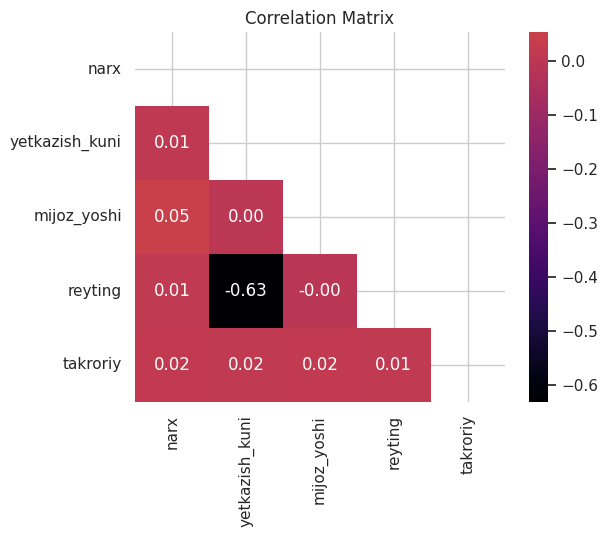

In [49]:
import numpy as np

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    annot=True,
    cmap="inferno",
    center=0,
    fmt=".2f",
    mask=mask,
    square=True
)

plt.title("Correlation Matrix")
plt.show()

Heatmap sonli o'zgaruvchilar orasidagi bog'liqlikni ko'rsatadi. Eng kuchli manfiy korrelyatsiya yetkazish muddati va mijoz reytingi orasida kuzatiladi. Qolgan o'zgaruvchilar o'rtasidagi bog'liqlik esa nisbatan kuchsiz bo'lib, ular bir-biriga katta darajada ta'sir qilmaydi.

In [61]:
# Takroriy mijozlar ulush

customer_counts = (
    df["takroriy"]
    .value_counts()
    .rename(index={0: "New", 1: "Returning"})
    .reset_index()
)

customer_counts.columns = ["Customer Type", "Count"]

fig = px.pie(
    customer_counts,
    names="Customer Type",
    values="Count",
    hole=0.45,
    template="plotly_dark"
    title="New vs Returning Customers"
)

fig.show()

# **Statistical Analysis**

In [54]:
# 1. Normality Test (Shapiro-Wilk)

sample = df["narx"].sample(500, random_state=42)

stat, p_value = stats.shapiro(sample)

print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.7f}")

alpha = 0.05

if p_value < alpha:
    print("Reject H0: The data is not normally distributed.")
else:
    print("Fail to reject H0: The data appears to be normally distributed.")

Statistic: 0.9807
P-value: 0.0000035
Reject H0: The data is not normally distributed.


Shapiro-Wilk testi narx ustunining normal taqsimotga mos kelishini tekshiradi. Nol gipoteza (H₀) ma'lumot normal taqsimlangan deb faraz qiladi. Agar p-value 0.05 dan kichik bo'lsa, H₀ rad etiladi va ma'lumot normal emas degan xulosaga kelinadi.

In [55]:
# 2. Confidence Interval (95%)

narx = df["narx"]

mean = narx.mean()
se = stats.sem(narx)

ci = stats.t.interval(
    confidence=0.95,
    df=len(narx)-1,
    loc=mean,
    scale=se
)

print(f"Mean: {mean:.2f}")
print(f"95% Confidence Interval: {ci}")

Mean: 135.69
95% Confidence Interval: (np.float64(133.12574064508772), np.float64(138.24679604254328))


Hisob-kitoblarga ko'ra buyurtmalarning o'rtacha narxi 135.69 ming so'mni tashkil etdi. 95% ishonch oralig'i esa 133.13 ming so'mdan 138.25 ming so'mgacha ekanligi aniqlandi.


Xulosa: 95% ishonch bilan aytish mumkinki, barcha buyurtmalarning haqiqiy o'rtacha narxi 133.13–138.25 ming so'm oralig'ida joylashgan.

In [57]:
# 3. T-test (asosiy qism)

chilonzor = df[df["filial"] == "Chilonzor"]["narx"]
yunusobod = df[df["filial"] == "Yunusobod"]["narx"]

t_stat, p_value = stats.ttest_ind(
    chilonzor,
    yunusobod
)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

T-statistic: -3.504
P-value: 0.0005
Reject H0


H₀ (Nol gipoteza):

Chilonzor va Yunusobod filiallarining o'rtacha buyurtma narxlari o'rtasida statistik jihatdan ahamiyatli farq yo'q.

H₁ (Muqobil gipoteza):

Chilonzor va Yunusobod filiallarining o'rtacha buyurtma narxlari o'rtasida statistik jihatdan ahamiyatli farq mavjud.

Chilonzor va Yunusobod filiallarining o'rtacha buyurtma narxlari o'rtasida statistik jihatdan ahamiyatli farq mavjud. Bu farq tasodifiy emas va filiallarning buyurtma narxlari bir-biridan sezilarli darajada farqlanishini ko'rsatadi

In [58]:
# 4. Pearson Correlation

corr = df["yetkazish_kuni"].corr(df["reyting"])

print(f"Pearson Correlation: {corr:.3f}")

Pearson Correlation: -0.632


Pearson korrelyatsiya koeffitsiyenti -0.632 ga teng bo'ldi. Bu qiymat yetkazish_kuni va reyting o'rtasida o'rtacha kuchli manfiy bog'liqlik mavjudligini bildiradi.

Xulosa: Yetkazib berish muddati uzaygan sari mijoz reytingi pasayish tendensiyasiga ega.

**Asosiy natijalar**

Buyurtma narxlari normal taqsimotga ega emasligi Shapiro-Wilk testi orqali aniqlandi.
Buyurtmalarning o'rtacha narxi 135.69 ming so'm bo'lib, haqiqiy o'rtacha qiymat 95% ishonch bilan 133.13–138.25 ming so'm oralig'ida joylashgan.
Chilonzor va Yunusobod filiallari o'rtasida buyurtma narxlari bo'yicha statistik jihatdan ahamiyatli farq mavjudligi T-test orqali tasdiqlandi.
Yetkazib berish muddati va mijoz reytingi o'rtasida -0.632 korrelyatsiya kuzatildi. Bu yetkazib berish tezligi oshgan sari mijozlar qoniqishi ham ortishini ko'rsatadi.

In [59]:
df.groupby("filial")["narx"].mean().sort_values(ascending=False)

,narx
filial,
Yunusobod,142.199782
Sergeli,138.733065
Mirobod,137.810032
Yakkasaroy,130.061716
Chilonzor,129.101288


# **Business qaror va xulosa**

***Business Insights***

Buyurtma narxlari normal taqsimotga ega emasligi aniqlandi. Bu narxlar taqsimotida yuqori qiymatlarning mavjudligini va ma'lumotlarning simmetrik emasligini ko'rsatadi.
Buyurtmalarning o'rtacha narxi 135.69 ming so'm bo'lib, haqiqiy o'rtacha qiymat 95% ishonch bilan 133.13–138.25 ming so'm oralig'ida joylashgan.
Chilonzor va Yunusobod filiallari o'rtasida buyurtma narxlari bo'yicha statistik jihatdan ahamiyatli farq mavjudligi aniqlandi.
Yetkazib berish muddati va mijoz reytingi o'rtasida o'rtacha kuchli manfiy bog'liqlik (-0.632) mavjud. Bu yetkazib berish tezligi mijozlar qoniqishiga sezilarli ta'sir ko'rsatishini anglatadi.

***Recommendations***

Yetkazib berish muddatini qisqartirish bo'yicha logistika jarayonlarini optimallashtirish tavsiya etiladi, chunki tezroq yetkazib berish yuqoriroq mijoz reytingi bilan bog'liq.
Filiallar o'rtasidagi narx farqining sabablarini qo'shimcha tahlil qilish tavsiya etiladi. Masalan, mahsulot assortimenti, chegirmalar yoki mijozlar tarkibi bu farqqa ta'sir qilishi mumkin.
Yuqori narxdagi buyurtmalar alohida segment sifatida tahlil qilinishi mumkin. Bu premium mijozlarning xarid odatlarini tushunishga yordam beradi.
Takroriy mijozlarning xarid xulqini alohida o'rganish orqali ularning sodiqligini oshirishga qaratilgan marketing strategiyalarini ishlab chiqish mumkin.

***Final Conclusion***

Ushbu mini-loyiha davomida Uzum Market buyurtmalari statistik va vizual tahlil qilindi. Dastlab ma'lumotlar tozalandi, yetishmayotgan qiymatlar va ekstremal kuzatuvlar qayta ishlanib, dataset tahlil uchun tayyorlandi. Shundan so'ng turli vizualizatsiyalar yordamida buyurtma narxlari, filiallar, mahsulot kategoriyalari hamda yetkazib berish muddati o'rtasidagi bog'liqliklar o'rganildi.

Statistik tahlil natijasida buyurtma narxlari normal taqsimotga ega emasligi, filiallar o'rtasida buyurtma narxlari bo'yicha sezilarli farq mavjudligi hamda yetkazib berish muddati uzaygan sari mijoz reytingi pasayishi aniqlandi. Ushbu natijalar biznes qarorlarini qabul qilishda foydali bo'lishi mumkin va ayniqsa logistika jarayonlarini optimallashtirish hamda mijozlar qoniqishini oshirish bo'yicha tavsiyalar ishlab chiqishga asos bo'lib xizmat qiladi.